# Class 1: Introduction to ML & Digit Recognition (60 minutes)

## 🎯 Learning Objectives
By the end of this class, you will be able to:
- Understand what machine learning classification means
- Load and visualize handwritten digit data
- Train your first k-Nearest Neighbors (k-NN) classifier
- Evaluate model performance using accuracy
- Recognize the connection between digit recognition and person identification

## ✍️ Handwriting Connection
Today we start our journey into handwriting analysis! Digit recognition is the foundation of understanding how computers can "read" handwritten text. The same principles we learn today will later help us identify who wrote a document by analyzing their unique writing patterns.

---

# Part 1: Setup & Motivation (10 minutes)

## What is Machine Learning Classification?
Classification is like teaching a computer to sort things into categories. Today we're teaching it to recognize which digit (0-9) someone wrote by hand.

**Real-world applications:**
- Post office sorting mail by zip codes
- Banks processing handwritten checks
- Digitizing historical documents
- **Our goal**: Eventually identifying people by their unique handwriting style!

In [1]:
# Import all necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


# Set style for better plots
plt.style.use("default")
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("📦 Using Python 3.12 with scikit-learn for machine learning")

✅ All libraries imported successfully!
📦 Using Python 3.12 with scikit-learn for machine learning


## 🔍 Let's Explore Our Handwritten Digits Dataset

The digits dataset contains 8x8 pixel images of handwritten digits (0-9). Each image is like a tiny digital photo of someone's handwriting!

In [2]:
# Load the digits dataset
digits = load_digits()

# Let's examine what we have
print("📊 Dataset Information:")
print(f"Number of samples: {len(digits.data)}")
print(f"Number of features per sample: {len(digits.data[0])}")
print(f"Image dimensions: 8x8 pixels = {8*8} features")
print(f"Number of classes (digits): {len(set(digits.target))}")
print(f"Classes: {list(set(digits.target))}")

# Store our features (X) and labels (y)
X = digits.data  # The actual pixel values
y = digits.target  # The correct digit labels (0-9)

print("\n🎯 Our goal: Given pixel values, predict which digit was written!")

📊 Dataset Information:
Number of samples: 1797
Number of features per sample: 64
Image dimensions: 8x8 pixels = 64 features
Number of classes (digits): 10
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

🎯 Our goal: Given pixel values, predict which digit was written!


### 🖼️ Visualizing Handwritten Digits

Let's see what our data actually looks like! Each digit is represented as 64 numbers (8x8 grid), where each number represents how dark that pixel is.

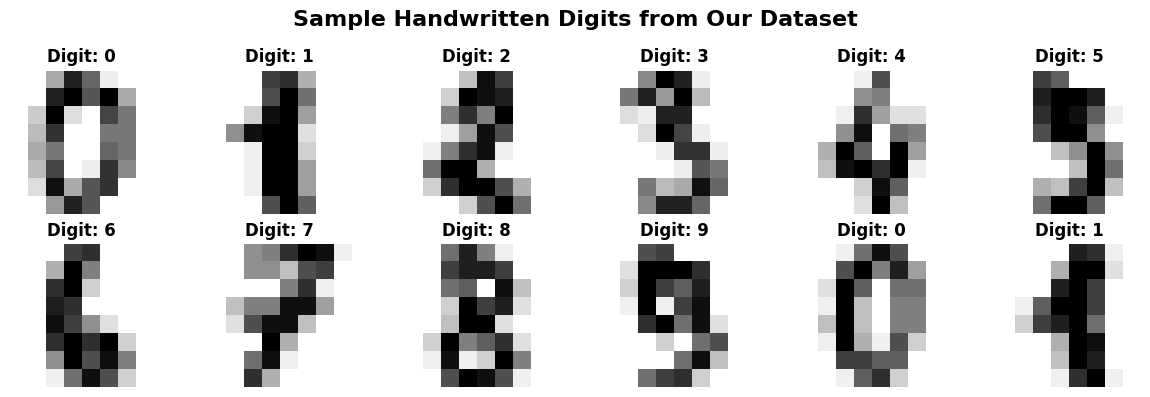

💡 Notice: Each person writes digits slightly differently!
   This variation is what we'll use later to identify individual writers.


In [5]:
# Create a visualization of the first 12 digits
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
fig.suptitle("Sample Handwritten Digits from Our Dataset", fontsize=16, fontweight="bold")

for i in range(12):
    row = i // 6
    col = i % 6

    # Show the digit image
    axes[row, col].imshow(digits.images[i], cmap="gray_r")
    axes[row, col].set_title(f"Digit: {digits.target[i]}", fontweight="bold")
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

print("💡 Notice: Each person writes digits slightly differently!")
print("   This variation is what we'll use later to identify individual writers.")

### 🔢 Understanding the Raw Data

Each image is stored as 64 numbers. Let's see what the raw data looks like:

First digit label: 0
Raw pixel values (0=white, 16=black):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]

Shaped as 8x8 image:
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


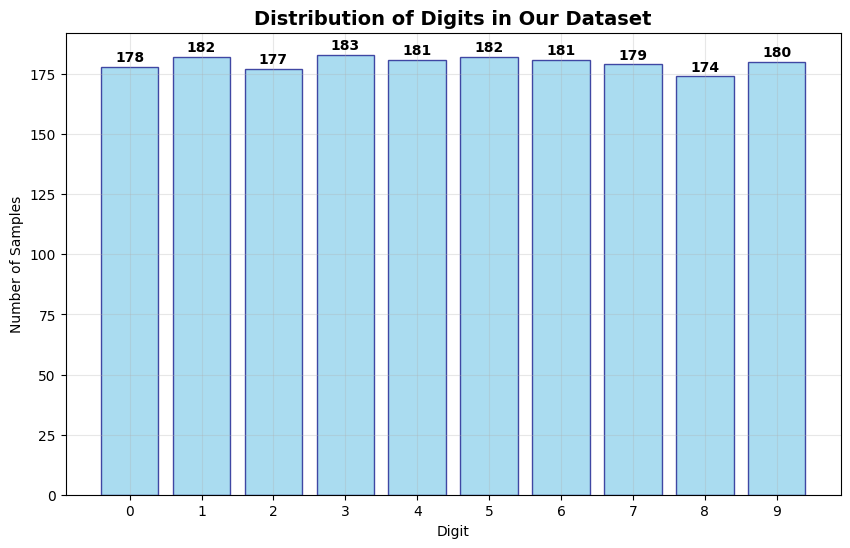

📈 Each digit appears roughly 180 times in our dataset


In [6]:
# Look at the raw pixel values for the first digit
print(f"First digit label: {y[0]}")
print("Raw pixel values (0=white, 16=black):")
print(X[0])

print("\nShaped as 8x8 image:")
print(digits.images[0])

# Let's see the distribution of digits in our dataset
plt.figure(figsize=(10, 6))
unique, counts = np.unique(y, return_counts=True)
bars = plt.bar(unique, counts, color="skyblue", edgecolor="navy", alpha=0.7)
plt.title("Distribution of Digits in Our Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")
plt.xticks(unique)

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.grid(True, alpha=0.3)
plt.show()

print(f"📈 Each digit appears roughly {counts.mean():.0f} times in our dataset")

---
# Part 2: Hands-On Implementation

## 🚀 Training Our First Machine Learning Model

Now let's build a system that can recognize handwritten digits! We'll use the k-Nearest Neighbors (k-NN) algorithm.

### 🤔 How k-NN Works (Simple Explanation)
Imagine you're trying to identify a mystery digit:
1. Look at the k most similar digits you've seen before
2. See what digits those similar ones were
3. Vote! The most common digit among your k neighbors is your prediction

It's like asking: "What did the most similar handwriting samples turn out to be?"

In [7]:
# Step 1: Split our data into training and testing sets
# This simulates having some samples to learn from, and others to test on
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # Use 20% for testing
    random_state=42,  # For reproducible results
    stratify=y,  # Keep same proportion of each digit
)

print("📚 Data Split Complete!")
print(f"Training samples: {len(X_train)} (used to teach the model)")
print(f"Testing samples: {len(X_test)} (used to evaluate performance)")
print(f"Training set contains {len(X_train)/len(X)*100:.1f}% of total data")

# Let's verify our split maintained the digit distribution
train_unique, train_counts = np.unique(y_train, return_counts=True)
test_unique, test_counts = np.unique(y_test, return_counts=True)

print(f"\n✅ Training set has digits: {train_unique}")
print(f"✅ Testing set has digits: {test_unique}")

📚 Data Split Complete!
Training samples: 1437 (used to teach the model)
Testing samples: 360 (used to evaluate performance)
Training set contains 80.0% of total data

✅ Training set has digits: [0 1 2 3 4 5 6 7 8 9]
✅ Testing set has digits: [0 1 2 3 4 5 6 7 8 9]


In [8]:
# Step 2: Create and train our k-NN classifier
# Let's start with k=3 (look at 3 most similar digits)
knn_classifier = KNeighborsClassifier(n_neighbors=3)

print("🎓 Training the k-NN classifier...")
print("   This means storing all training samples for later comparison")

# Train the model (this is very fast for k-NN!)
knn_classifier.fit(X_train, y_train)

print("✅ Training complete!")
print(f"   Model learned from {len(X_train)} digit samples")
print("   For each new digit, it will find the 3 most similar training samples")

🎓 Training the k-NN classifier...
   This means storing all training samples for later comparison
✅ Training complete!
   Model learned from 1437 digit samples
   For each new digit, it will find the 3 most similar training samples


In [9]:
# Step 3: Make predictions on our test set
print("🔮 Making predictions on test data...")

y_pred = knn_classifier.predict(X_test)

print("✅ Predictions complete!")
print(f"   Made predictions for {len(X_test)} test digits")

# Let's see some example predictions
print("\nExample predictions:")
print("Actual → Predicted")
for i in range(10):
    actual = y_test[i]
    predicted = y_pred[i]
    status = "✅" if actual == predicted else "❌"
    print(f"   {actual} → {predicted} {status}")

🔮 Making predictions on test data...
✅ Predictions complete!
   Made predictions for 360 test digits

Example predictions:
Actual → Predicted
   5 → 5 ✅
   2 → 2 ✅
   8 → 8 ✅
   1 → 1 ✅
   7 → 7 ✅
   2 → 2 ✅
   6 → 6 ✅
   2 → 2 ✅
   6 → 6 ✅
   5 → 5 ✅


In [10]:
# Step 4: Evaluate our model's performance
accuracy = accuracy_score(y_test, y_pred)

print("📊 Model Performance Results:")
print(f"🎯 Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"   This means we correctly identified {accuracy*100:.1f}% of handwritten digits!")

# Calculate how many we got right vs wrong
correct_predictions = (y_test == y_pred).sum()
total_predictions = len(y_test)
wrong_predictions = total_predictions - correct_predictions

print("\n📈 Detailed Results:")
print(f"   ✅ Correct predictions: {correct_predictions}")
print(f"   ❌ Wrong predictions: {wrong_predictions}")
print(f"   📊 Total predictions: {total_predictions}")

📊 Model Performance Results:
🎯 Accuracy: 0.986 (98.6%)
   This means we correctly identified 98.6% of handwritten digits!

📈 Detailed Results:
   ✅ Correct predictions: 355
   ❌ Wrong predictions: 5
   📊 Total predictions: 360


### 🎨 Visualizing Our Results

Let's see some examples where our model was right and where it struggled:

/var/folders/x_/3_4lp_2n1rd1168j0nx58_7w0000gp/T/ipykernel_84832/821137106.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x_/3_4lp_2n1rd1168j0nx58_7w0000gp/T/ipykernel_84832/821137106.py:32: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/niltonfrat/Library/Caches/pypoetry/virtualenvs/ml-learning-CTEhLkrF-py3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/niltonfrat/Library/Caches/pypoetry/virtualenvs/ml-learning-CTEhLkrF-py3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


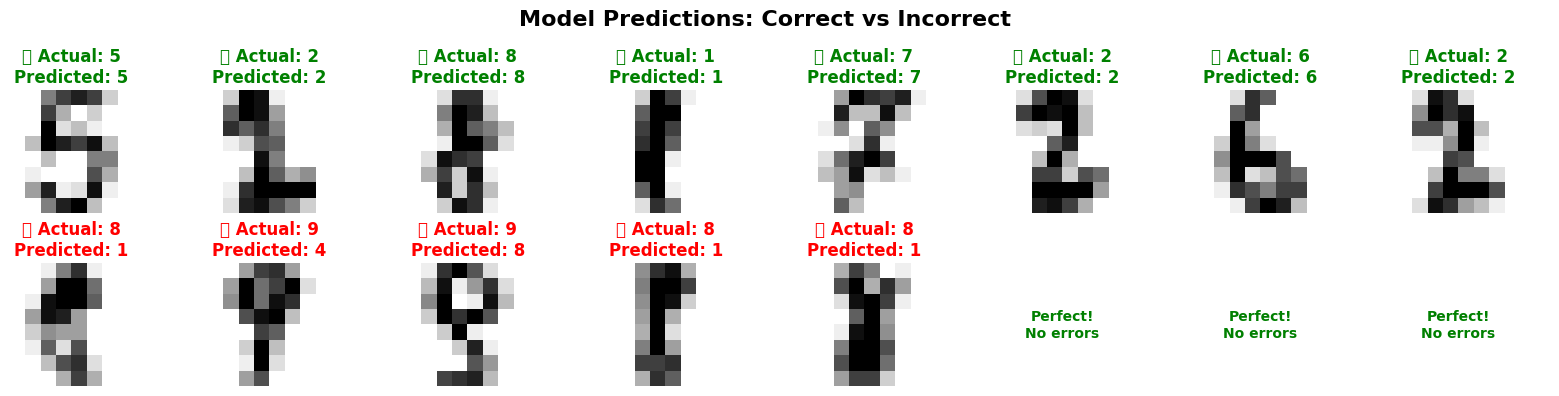

🎉 Great job! Our model achieved 98.6% accuracy
🔍 The errors show us which digits are hardest to distinguish


In [11]:
# Find some correct and incorrect predictions for visualization
correct_indices = np.where(y_test == y_pred)[0]
incorrect_indices = np.where(y_test != y_pred)[0]

# Create visualization
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("Model Predictions: Correct vs Incorrect", fontsize=16, fontweight="bold")

# Show 8 correct predictions
for i in range(8):
    if i < len(correct_indices):
        idx = correct_indices[i]
        axes[0, i].imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
        axes[0, i].set_title(
            f"✅ Actual: {y_test[idx]}\nPredicted: {y_pred[idx]}",
            fontweight="bold",
            color="green",
        )
        axes[0, i].axis("off")

# Show 8 incorrect predictions (if any exist)
for i in range(8):
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]
        axes[1, i].imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
        axes[1, i].set_title(
            f"❌ Actual: {y_test[idx]}\nPredicted: {y_pred[idx]}",
            fontweight="bold",
            color="red",
        )
        axes[1, i].axis("off")
    else:
        axes[1, i].axis("off")
        axes[1, i].text(
            0.5,
            0.5,
            "Perfect!\nNo errors",
            ha="center",
            va="center",
            transform=axes[1, i].transAxes,
            fontweight="bold",
            color="green",
        )

plt.tight_layout()
plt.show()

print(f"🎉 Great job! Our model achieved {accuracy*100:.1f}% accuracy")
if len(incorrect_indices) > 0:
    print("🔍 The errors show us which digits are hardest to distinguish")
else:
    print("🏆 Perfect score! No errors on this test set!")

### 🧪 Experiment: What if we change k?

Let's see how different values of k (number of neighbors) affect our results:

🔬 Experimenting with different k values:
k= 1: 0.986 (98.6%)
k= 3: 0.986 (98.6%)
k= 5: 0.983 (98.3%)
k= 7: 0.983 (98.3%)
k= 9: 0.981 (98.1%)
k=11: 0.978 (97.8%)
k=15: 0.975 (97.5%)
k=20: 0.967 (96.7%)


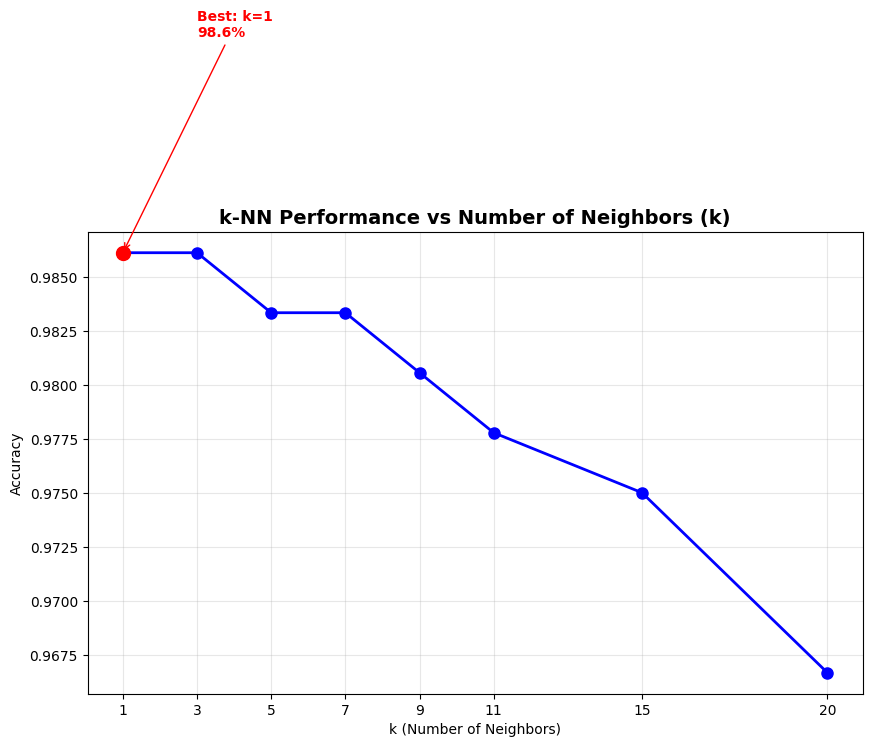


🏆 Best performance: k=1 with 98.6% accuracy


In [12]:
# Test different values of k
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
accuracies = []

print("🔬 Experimenting with different k values:")

for k in k_values:
    # Train a new model with this k value
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)

    # Make predictions and calculate accuracy
    y_pred_k = knn_k.predict(X_test)
    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)

    print(f"k={k:2d}: {accuracy_k:.3f} ({accuracy_k*100:.1f}%)")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, "bo-", linewidth=2, markersize=8)
plt.title("k-NN Performance vs Number of Neighbors (k)", fontsize=14, fontweight="bold")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Highlight the best k
best_k_idx = np.argmax(accuracies)
best_k = k_values[best_k_idx]
best_accuracy = accuracies[best_k_idx]

plt.scatter(best_k, best_accuracy, color="red", s=100, zorder=5)
plt.annotate(
    f"Best: k={best_k}\n{best_accuracy*100:.1f}%",
    xy=(best_k, best_accuracy),
    xytext=(best_k + 2, best_accuracy + 0.01),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontweight="bold",
    color="red",
)

plt.show()

print(f"\n🏆 Best performance: k={best_k} with {best_accuracy*100:.1f}% accuracy")

---
# Part 3: Interpretation & Discussion (10 minutes)

## 🔍 Understanding Our Results

Let's dive deeper into what our model learned and where it struggles:

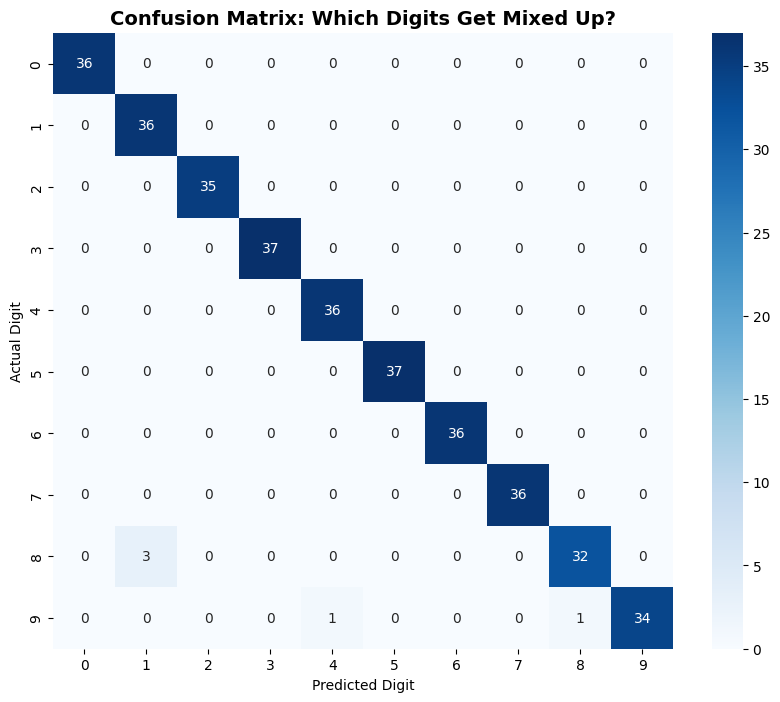

📊 Confusion Matrix Analysis:
   • Diagonal values = correct predictions
   • Off-diagonal values = mistakes

🔍 Most common mistakes:
   • Digit 8 mistaken for 1: 3 times
   • Digit 9 mistaken for 4: 1 times
   • Digit 9 mistaken for 8: 1 times


In [13]:
# Create a confusion matrix to see which digits get confused
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix: Which Digits Get Mixed Up?", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()

# Analyze the confusion matrix
print("📊 Confusion Matrix Analysis:")
print("   • Diagonal values = correct predictions")
print("   • Off-diagonal values = mistakes")
print("\n🔍 Most common mistakes:")

# Find the biggest off-diagonal values
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            print(f"   • Digit {i} mistaken for {j}: {cm[i, j]} times")

In [14]:
# Generate a detailed classification report
report = classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)], output_dict=True)

print("📈 Detailed Performance Report:")
print("\nPer-digit performance:")
for digit in range(10):
    digit_str = str(digit)
    precision = report[digit_str]["precision"]
    recall = report[digit_str]["recall"]
    f1 = report[digit_str]["f1-score"]
    support = report[digit_str]["support"]

    print(f"Digit {digit}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f} (n={support})")

print("\n🎯 Overall Performance:")
print(f"   • Accuracy: {report['accuracy']:.3f}")
print(f"   • Macro Average F1: {report['macro avg']['f1-score']:.3f}")
print(f"   • Weighted Average F1: {report['weighted avg']['f1-score']:.3f}")

📈 Detailed Performance Report:

Per-digit performance:
Digit 0: Precision=1.000, Recall=1.000, F1=1.000 (n=36.0)
Digit 1: Precision=0.923, Recall=1.000, F1=0.960 (n=36.0)
Digit 2: Precision=1.000, Recall=1.000, F1=1.000 (n=35.0)
Digit 3: Precision=1.000, Recall=1.000, F1=1.000 (n=37.0)
Digit 4: Precision=0.973, Recall=1.000, F1=0.986 (n=36.0)
Digit 5: Precision=1.000, Recall=1.000, F1=1.000 (n=37.0)
Digit 6: Precision=1.000, Recall=1.000, F1=1.000 (n=36.0)
Digit 7: Precision=1.000, Recall=1.000, F1=1.000 (n=36.0)
Digit 8: Precision=0.970, Recall=0.914, F1=0.941 (n=35.0)
Digit 9: Precision=1.000, Recall=0.944, F1=0.971 (n=36.0)

🎯 Overall Performance:
   • Accuracy: 0.986
   • Macro Average F1: 0.986
   • Weighted Average F1: 0.986


## 🧠 Key Concepts We Learned

### 1. **Classification**
- Assigning labels (digit 0-9) to input data (pixel values)
- Supervised learning: we have examples with correct answers

### 2. **k-Nearest Neighbors (k-NN)**
- Simple but effective algorithm
- Makes predictions based on similarity to training examples
- No complex math, just finding "similar" samples

### 3. **Train/Test Split**
- Train on some data, test on different data
- Prevents overfitting (memorizing instead of learning)
- Simulates real-world performance

### 4. **Accuracy**
- Percentage of correct predictions
- Simple but important metric
- Not the only metric that matters!

## 🔮 Connection to Handwriting Recognition

Today's digit recognition is the foundation for:
- **Letter recognition** (coming next class!)
- **Word recognition** 
- **Writing style analysis**
- **Person identification from handwriting**

---
# Part 4: Wrap-up & Preview

## 🎉 What You Accomplished Today

✅ **Loaded and explored** a real handwriting dataset  
✅ **Trained** your first machine learning model  
✅ **Made predictions** on new handwritten digits  
✅ **Evaluated performance** using accuracy  
✅ **Experimented** with different parameters (k values)  
✅ **Analyzed results** to understand model behavior  

## 🏠 Assignment for Next Class

### Quick Check Questions:
1. What does k=1 mean in k-NN? What about k=20?
2. Why might k=1 sometimes perform worse than k=3?
3. Which digits in our dataset were hardest to classify correctly?

### Practice Exercise:
Run the experiments below and bring your results to discuss:

In [15]:
# Assignment Code - Run these experiments!

print("🏠 ASSIGNMENT EXPERIMENTS")
print("=" * 50)

# Experiment 1: Try k=1 vs k=21
print("\n1. Comparing extreme k values:")
for k in [1, 21]:
    knn_exp = KNeighborsClassifier(n_neighbors=k)
    knn_exp.fit(X_train, y_train)
    y_pred_exp = knn_exp.predict(X_test)
    acc_exp = accuracy_score(y_test, y_pred_exp)
    print(f"   k={k}: {acc_exp:.3f} ({acc_exp*100:.1f}%)")

# Experiment 2: Analyze hardest digits to classify
print("\n2. Which digits are hardest to classify?")
digit_accuracies = []
for digit in range(10):
    digit_mask = y_test == digit
    if digit_mask.sum() > 0:  # Make sure we have samples of this digit
        digit_accuracy = (y_pred[digit_mask] == digit).mean()
        digit_accuracies.append((digit, digit_accuracy))

# Sort by accuracy (worst first)
digit_accuracies.sort(key=lambda x: x[1])
print("   Ranking (hardest to easiest):")
for i, (digit, acc) in enumerate(digit_accuracies):
    print(f"   {i+1}. Digit {digit}: {acc:.3f} ({acc*100:.1f}%)")

print("\n💭 Think about: Why might some digits be harder than others?")
print("    Hint: Look at the digit images - which ones look similar?")

🏠 ASSIGNMENT EXPERIMENTS

1. Comparing extreme k values:
   k=1: 0.986 (98.6%)
   k=21: 0.964 (96.4%)

2. Which digits are hardest to classify?
   Ranking (hardest to easiest):
   1. Digit 8: 0.914 (91.4%)
   2. Digit 9: 0.944 (94.4%)
   3. Digit 0: 1.000 (100.0%)
   4. Digit 1: 1.000 (100.0%)
   5. Digit 2: 1.000 (100.0%)
   6. Digit 3: 1.000 (100.0%)
   7. Digit 4: 1.000 (100.0%)
   8. Digit 5: 1.000 (100.0%)
   9. Digit 6: 1.000 (100.0%)
   10. Digit 7: 1.000 (100.0%)

💭 Think about: Why might some digits be harder than others?
    Hint: Look at the digit images - which ones look similar?


### Extension Challenge (Optional):
Try collecting your own handwritten digits! Take photos or scan handwritten numbers 0-9 and see if you can get them into a similar 8x8 format. How well does our model work on YOUR handwriting?

### Reflection Questions:
1. **Real-world applications**: Where else might digit recognition be useful?
2. **Limitations**: What problems might arise when using this model in practice?
3. **Next steps**: How could we improve our digit recognition system?

## 🔮 Next Class Preview: Letter Recognition

Next week we'll move from digits to letters! We'll use **Decision Trees** to classify letters A-Z and learn about **feature importance** - which aspects of handwriting matter most for recognition.

**Spoiler**: This gets us one step closer to identifying who wrote a document! 🕵️‍♂️

---
### 📚 Key Terms Glossary

- **Classification**: Predicting categories/labels for input data
- **k-NN**: Algorithm that predicts based on k most similar training examples  
- **Training Set**: Data used to teach the model
- **Test Set**: Data used to evaluate model performance
- **Accuracy**: Percentage of correct predictions
- **Feature**: Individual input variable (pixel value in our case)
- **Confusion Matrix**: Table showing prediction vs actual results
- **Overfitting**: Model memorizes training data instead of learning patterns

**Great work today! You're now officially a machine learning practitioner! 🎓**